<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter18_NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 18: Neural Networks

🎓 **Course:** BIFX-546 – Machine Learning for Bioinformatics  
👨‍🏫 **Instructor:** Sarangan Ravichandran, PhD., PMP

## 📘 Attribution & Reading Reference

This notebook is based on concepts, structure, and examples from:

> *Data Science from Scratch*, 2nd Edition — Joel Grus, O'Reilly Media  
> **Relevant chapter:** Chapter 18 — Neural Networks

The material has been **expanded with additional explanations, new examples, LaTeX math, and bioinformatics parallels** to support instructional use in Google Colab. Any additions, reformatting, or implementation details beyond the original text are the responsibility of the notebook author.

*This notebook is intended for educational use only and does not replace the original text.*

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. Describe the biological motivation for artificial neural networks and the perceptron model.
2. Implement AND, OR, and NOT logic gates using a perceptron.
3. Explain why a single perceptron cannot solve XOR, and how a hidden layer resolves this.
4. Build a feed-forward neural network and trace the forward pass step by step.
5. Explain the role of the sigmoid activation function and why it replaces the step function.
6. Understand backpropagation conceptually: loss → gradients → weight updates.
7. Train a neural network from scratch using gradient descent.
8. Apply a from-scratch neural network to the FizzBuzz classification problem.
9. Connect neural network concepts to bioinformatics applications (gene expression, sequence classification).

## ⚙️ Environment Setup

We clone the course repository to access the `scratch` helper modules used throughout the Grus text.


In [64]:
# @title
import os

# Clone repo only if we are not already inside it
if not os.path.exists('scratch'):
    if not os.path.exists('dsfs'):
        !git clone https://github.com/joelgrus/data-science-from-scratch dsfs
    os.chdir('dsfs')

import sys
if '.' not in sys.path:
    sys.path.insert(0, '.')

print('Working directory:', os.getcwd())
print('scratch package available:', os.path.isdir('scratch'))

Working directory: /content/dsfs
scratch package available: True


In [65]:
# @title
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import List

# Grus helper modules
from scratch.linear_algebra import Vector, dot
from scratch.gradient_descent import gradient_step

print('All imports successful.')

All imports successful.


---
## 1. Biological Motivation

The human brain contains roughly **86 billion neurons**, each connected to thousands of others via synapses. A neuron receives electrochemical signals from its neighbours, sums them up, and *fires* (emits a signal of its own) only when the total exceeds a threshold.

An **artificial neural network (ANN)** mimics this at an abstract level:

| Biological | Artificial |
|---|---|
| Neuron | Node / unit |
| Synapse strength | Weight $w$ |
| Firing threshold | Activation function |
| Axon output | Neuron output value |

### 🧬 Bioinformatics Connection
Neural networks are central to modern bioinformatics:
- **Gene expression classification** — identify cancer subtypes from RNA-seq profiles
- **Protein structure prediction** — AlphaFold2 uses transformer-based deep networks
- **DNA sequence motif detection** — convolutional networks scan raw sequences for binding sites
- **Drug–target interaction** — predict whether a compound binds a protein

> ⚠️ **Black-box caveat (Grus):** Most neural networks are difficult to interpret. For many bioinformatics tasks, simpler interpretable models (logistic regression, decision trees) are preferred unless raw performance is paramount.

## 2. The Perceptron

The **perceptron** is the simplest neural network — a single neuron with $n$ binary inputs.

Pretty much the simplest neural network is the perceptron, which approximates a single neuron with n binary inputs. It computes a weighted sum of its inputs and “fires” if that weighted sum is 0 or greater:

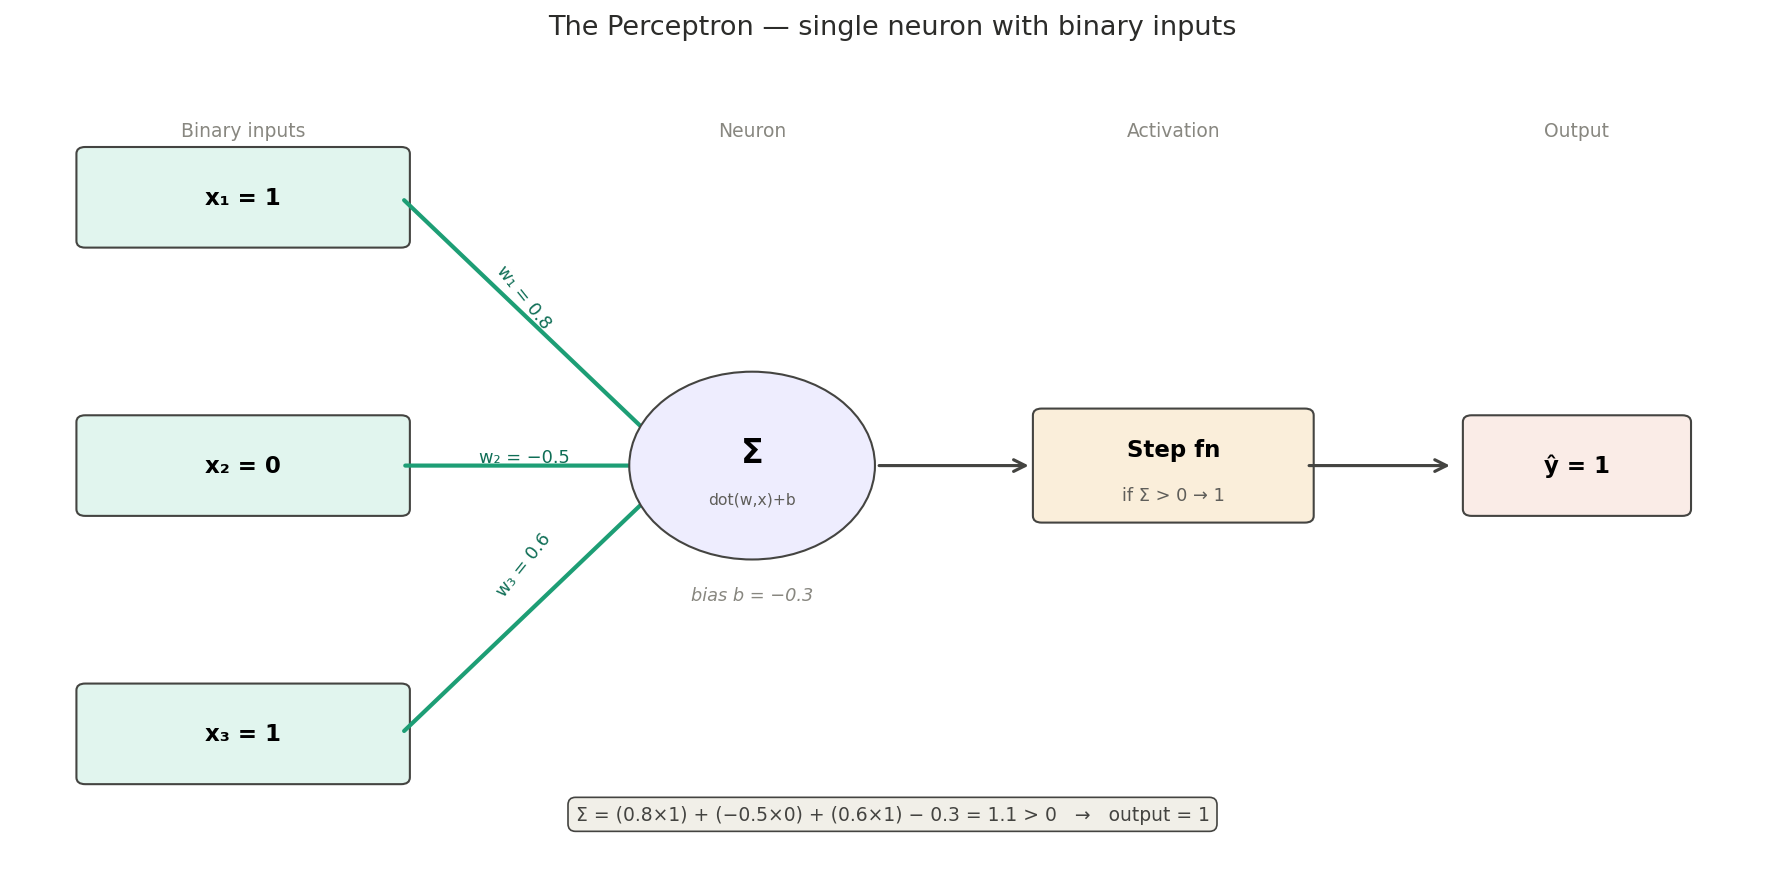

In [66]:
from IPython.display import Image, display

base = "https://raw.githubusercontent.com/ravichas/bifx-546/main/images/"

display(Image(base + "perceptron.png"))

In [67]:
def step_function(x: float) -> float:
    """Fires (returns 1) if x >= 0, silent (returns 0) otherwise."""
    return 1.0 if x >= 0 else 0.0

def perceptron_output(weights: Vector, bias: float, x: Vector) -> float:
    """Returns 1 if the perceptron 'fires', 0 otherwise."""
    calculation = dot(weights, x) + bias
    return step_function(calculation)

print('Perceptron functions defined.')

Perceptron functions defined.


### 2.2 Logic Gates with a Perceptron

To summarize, a perceptron computes dot(w, x) + bias and fires if the result > 0.

A logic gate is just a perceptron where:

* inputs are always 0 or 1
* the rule (threshold) is fixed and known in advance
* you're not learning weights — the weights are hand-set to enforce the rule

We can hand-craft weights to implement boolean logic. Let's verify all three.

**AND gate** — fires only when *both* inputs are 1:

$$z = 2x_1 + 2x_2 - 3$$

| $x_1$ | $x_2$ | $z$ | output |
|---|---|---|---|
| 1 | 1 | 1 | **1** |
| 1 | 0 | -1 | 0 |
| 0 | 1 | -1 | 0 |
| 0 | 0 | -3 | 0 |

```
# AND gate — separate (1,1) from the other three
and_weights = [2., 2.]
and_bias    = -3.

perceptron_output(and_weights, and_bias, [1, 1])  # → 1  (above the line)
perceptron_output(and_weights, and_bias, [1, 0])  # → 0  (below the line)
perceptron_output(and_weights, and_bias, [0, 1])  # → 0  (below the line)
perceptron_output(and_weights, and_bias, [0, 0])  # → 0  (below the line)

# OR gate — separate (0,0) from the other three
or_weights = [2., 2.]
or_bias    = -1.

perceptron_output(or_weights, or_bias, [1, 1])  # → 1  (above the line)
perceptron_output(or_weights, or_bias, [1, 0])  # → 1  (above the line)
perceptron_output(or_weights, or_bias, [0, 1])  # → 1  (above the line)
perceptron_output(or_weights, or_bias, [0, 0])  # → 0  (below the line)
```

In [68]:
# AND gate
and_weights = [2., 2]
and_bias = -3.

assert perceptron_output(and_weights, and_bias, [1, 1]) == 1
assert perceptron_output(and_weights, and_bias, [0, 1]) == 0
assert perceptron_output(and_weights, and_bias, [1, 0]) == 0
assert perceptron_output(and_weights, and_bias, [0, 0]) == 0
print('AND gate: all assertions passed ✓')

# OR gate
or_weights = [2., 2]
or_bias = -1.

assert perceptron_output(or_weights, or_bias, [1, 1]) == 1
assert perceptron_output(or_weights, or_bias, [0, 1]) == 1
assert perceptron_output(or_weights, or_bias, [1, 0]) == 1
assert perceptron_output(or_weights, or_bias, [0, 0]) == 0
print('OR gate:  all assertions passed ✓')

# NOT gate (single input)
not_weights = [-2.]
not_bias = 1.

assert perceptron_output(not_weights, not_bias, [0]) == 1
assert perceptron_output(not_weights, not_bias, [1]) == 0
print('NOT gate: all assertions passed ✓')

AND gate: all assertions passed ✓
OR gate:  all assertions passed ✓
NOT gate: all assertions passed ✓


### 2.3 The XOR Problem — The Perceptron's Limit

**XOR** (exclusive OR) outputs 1 only when exactly *one* input is 1:

| $x_1$ | $x_2$ | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

The two *positive* points (0,1) and (1,0) cannot be separated from the two *negative* points (0,0) and (1,1) by any straight line — the classes are **not linearly separable**. No single perceptron can solve XOR. We need a **hidden layer**.

> 💡 This limitation was famously documented by Minsky & Papert (1969), and it temporarily slowed neural network research until **multi-layer** approaches were developed.

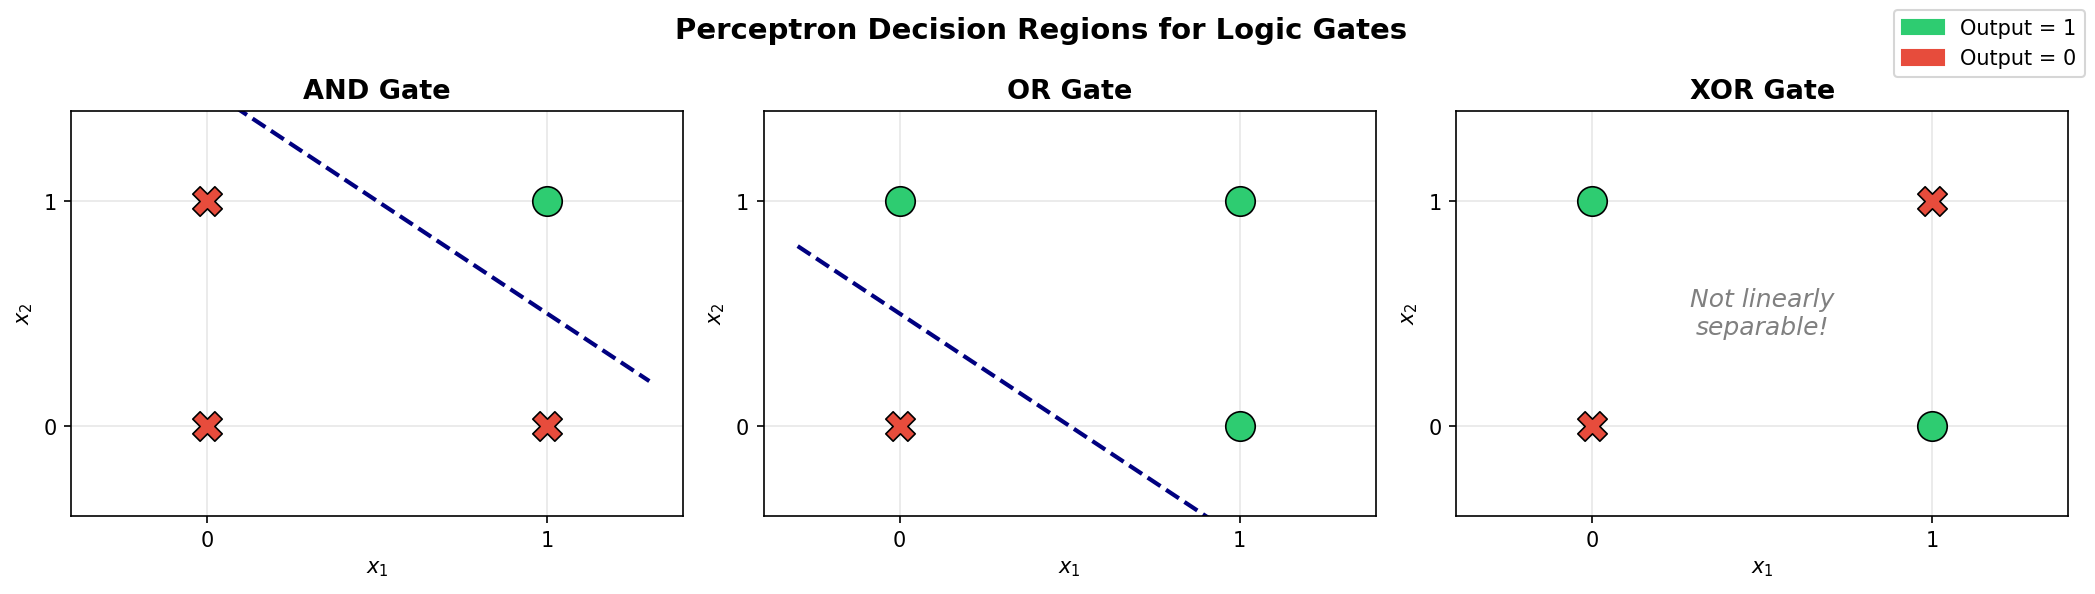

In [69]:
display(Image(base + "perceptron_regions.png"))

## 3. From Step Function to Sigmoid

XOR showed us that one perceptron is not enough. We need to
stack multiple perceptrons — each one feeding its output into
the next. That stacking is what makes a neural network.

But stacking creates a new problem.

Each perceptron uses a **step function** — output is hard 0 or 1:

    output = 1 if z > 0 else 0

When we want to train the network by adjusting weights, we need
to ask: "if I nudge this weight slightly, does the output get
better or worse?" The step function cannot answer that.

Look at its shape:

         1 |        ┌────────
           |        │
         0 |────────┘
                   z=0

It is completely flat everywhere except at z=0 where it jumps
instantly. Flat means zero slope. Zero slope means gradient
descent has nothing to follow — it cannot learn.

The fix is to replace the hard jump with a smooth curve.
That is exactly what sigmoid does:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

(see below for the sigmoid curve)

Now a small nudge to a weight produces a small measurable
change in output. Gradient descent can follow that signal.

**Key properties:**
* Range: (0, 1) — outputs interpretable as probabilities
* Differentiable everywhere: σ′(z) = σ(z)(1 − σ(z))
* Smooth approximation of the step function
* Saturates at extremes (gradients → 0 for large |z|)
  — this is the **vanishing gradient problem**

📝 You saw **sigmoid in Chapter 16 (Logistic Regression) as
the logistic function.** Same function, new role — there it
produced a probability, here it keeps the network trainable.

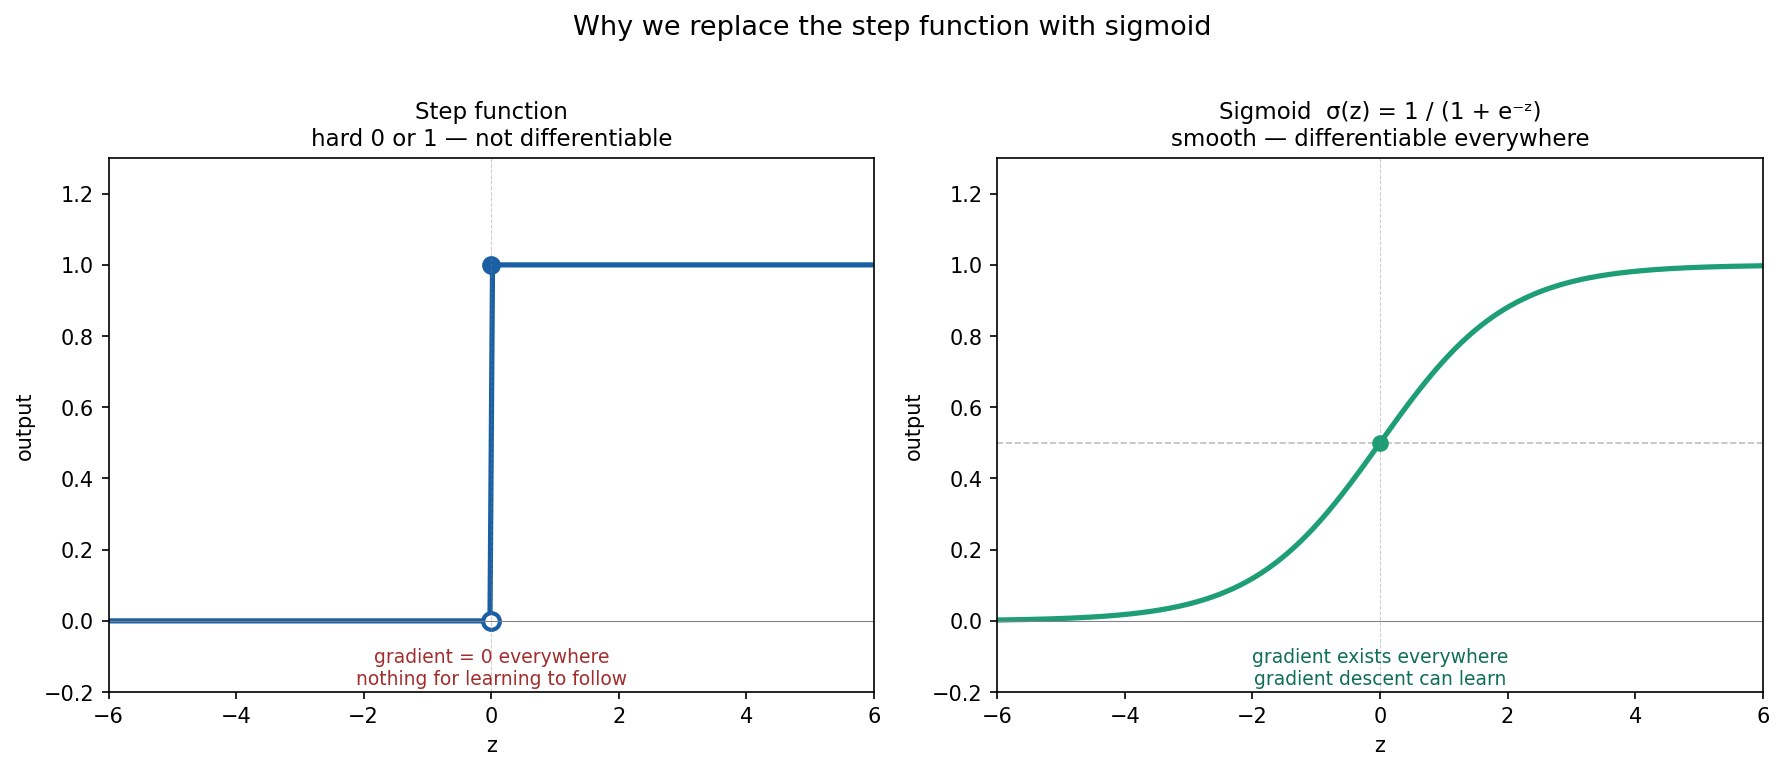

In [70]:
display(Image(base + "step_vs_sigmoid.png"))

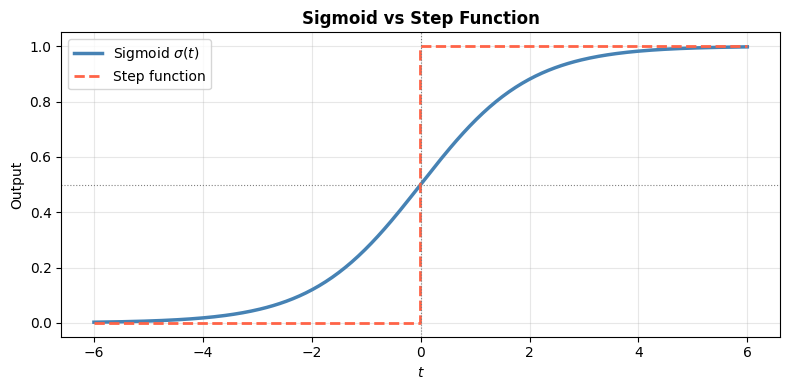

sigma(2.0) = 0.8808
sigma'(2.0) = sigma*(1-sigma) = 0.1050


In [71]:
# @title
import math
def sigmoid(t: float) -> float:
    """Sigmoid (logistic) activation function."""
    return 1 / (1 + math.exp(-t))

# Visualise sigmoid vs step
t_vals = np.linspace(-6, 6, 300)
sig_vals = [sigmoid(t) for t in t_vals]
step_vals = [1.0 if t >= 0 else 0.0 for t in t_vals]

plt.figure(figsize=(8, 4))
plt.plot(t_vals, sig_vals, color='steelblue', lw=2.5, label='Sigmoid $\\sigma(t)$')
plt.step(t_vals, step_vals, color='tomato', lw=2, linestyle='--', label='Step function')
plt.axhline(0.5, color='gray', lw=0.8, ls=':')
plt.axvline(0, color='gray', lw=0.8, ls=':')
plt.xlabel('$t$'); plt.ylabel('Output')
plt.title('Sigmoid vs Step Function', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show derivative property
s = sigmoid(2.0)
print(f'sigma(2.0) = {s:.4f}')
print(f"sigma'(2.0) = sigma*(1-sigma) = {s*(1-s):.4f}")

## 4. The Artificial Neuron

In a feed-forward network, each neuron:
1. Receives inputs $\mathbf{x}$ (with a constant 1 appended for the bias)
2. Computes the dot product with weights $\mathbf{w}$ (bias absorbed in)
3. Applies the sigmoid activation

The trick is to absorb the bias into the weight vector:

$$
\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \\ 1 \end{bmatrix}
\qquad
\mathbf{w} = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \\ b \end{bmatrix}
$$

So the dot product automatically includes the bias:

$$
\mathbf{w} \cdot \mathbf{x} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b \cdot 1
$$

And the full neuron output is:


$$\text{output} = \sigma\!\left(\sum_i w_i x_i\right) = \sigma(\mathbf{w} \cdot \mathbf{x})$$

> **Why do this?** Instead of writing $\sigma\!\left(\sum_i w_i x_i + b\right)$
> every time with a separate $b$, we append $1$ to $\mathbf{x}$ and let
> $\mathbf{w}$ carry the bias as its last element. One clean dot product
> does everything. This is the Grus convention.

In [72]:
def neuron_output(weights: Vector, inputs: Vector) -> float:
    """
    Compute single neuron output.
    weights includes the bias weight (last element).
    inputs must include a trailing 1 for the bias.
    """
    return sigmoid(dot(weights, inputs))

# Quick sanity check
# weights = [w1, w2, bias_weight]; inputs = [x1, x2, 1]
out = neuron_output([0.5, -0.3, 0.1], [1.0, 2.0, 1.0])
print(f'Example neuron output: {out:.4f}')

Example neuron output: 0.5000


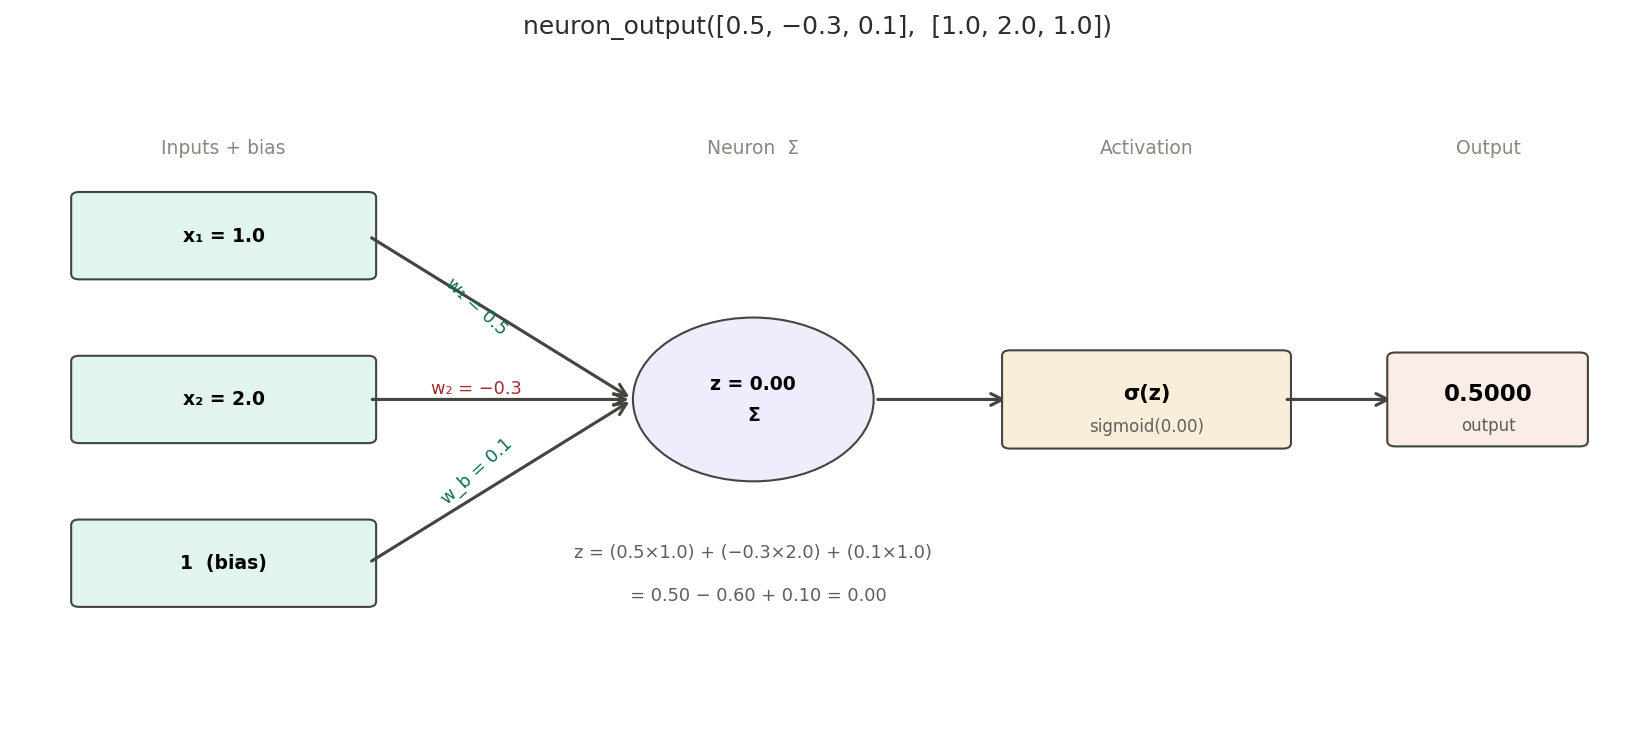

In [73]:
display(Image(base + "neuron_output.png"))

```
z = 0.0000   →   σ(z) = 0.5000
```

---
## 5. Feed-Forward Neural Networks

A feed-forward network is organised in **layers**:

- **Input layer** — passes raw features forward unchanged
- **Hidden layer(s)** — learn intermediate representations (features of features)
- **Output layer** — produces predictions

### Data structure

```
network = [ layer_1, layer_2, ... ]
layer   = [ neuron_1, neuron_2, ... ]
neuron  = [ w_1, w_2, ..., w_n, bias_weight ]
```

### Forward pass

For each layer, append a 1 to the input (bias), compute each neuron's output, collect results, and feed them into the next layer.

$$\mathbf{h} = \sigma(W^{(1)} \mathbf{x})$$
$$\widehat{y} = \sigma(W^{(2)} \mathbf{h})$$

# Remember

```python
Vector = List[float]        # e.g. [0.5, -0.3, 0.1]

List[Vector]                # e.g. [[0.5, -0.3], [0.2, 0.8]]

List[List[Vector]]          # the full network

# Here is a concreate example

# Layer 1: 2 neurons (AND, OR), each with 3 weights [w1, w2, bias]
layer1 = [
    [20., 20., -30.],    # AND neuron weights
    [20., 20., -10.],    # OR  neuron weights
]

# Layer 2: 1 neuron (output), with 3 weights
layer2 = [
    [-60., 60., -30.],   # output neuron weights
]

# Full network
network = [layer1, layer2]

List [ List[Vector] ]
  │        │
  │        └── one layer = all neurons in that layer
  │                        each neuron = one Vector of weights
  │
  └── the full network = all layers stacked

```

In [74]:
def feed_forward(neural_network: List[List[Vector]],
                  input_vector: Vector) -> List[Vector]:
    """
    Run a forward pass through the entire network.
    Returns a list of output vectors — one per layer (not just the last).
    This is needed by backpropagation, which requires intermediate activations.
    """
    outputs: List[Vector] = []
    for layer in neural_network:
        # this appends the list [1, 2] + [1] -> [1, 2, 1]
        input_with_bias = input_vector + [1]          # append bias term
        output = [neuron_output(neuron, input_with_bias)
                  for neuron in layer]                # one output per neuron
        outputs.append(output)
        input_vector = output                         # output becomes next input
    # print(outputs)
    return outputs

print('feed_forward() defined.')

feed_forward() defined.


### 5.1 Solving XOR with a Hidden Layer

XOR = OR ∧ ¬AND = "or, but not and".

We hand-craft a two-layer network:
- **Hidden layer:** one neuron approximates AND, another approximates OR
- **Output layer:** one neuron computes (OR output) AND NOT (AND output)

Large weights push the sigmoid to its 0/1 saturation points,
effectively recovering the step-function behaviour.

```
        [AND neuron]  \
x1, x2 <             > [output neuron] → XOR
        [OR  neuron]  /
```

In [75]:
xor_network = [
    # Hidden layer — 2 inputs → 2 neurons
    [[20., 20, -30],   # AND neuron: fires when BOTH inputs are 1
     [20., 20, -10]],  # OR  neuron: fires when AT LEAST ONE input is 1
    # Output layer — 2 hidden inputs → 1 neuron
    [[-60., 60, -30]]  # fires when OR=1 but AND=0  (i.e. exactly one input)
]

inputs = [[0, 0], [1, 0], [0, 1], [1, 1]]
expected = [0, 1, 1, 0]

print('XOR Network Verification')
print('-' * 38)
print(f'{"Input":<12} {"Expected":<12} {"Output":<10} {"OK"}')
print('-' * 38)
for x, exp in zip(inputs, expected):
    out = feed_forward(xor_network, x)[-1][0]
    ok = '✓' if (exp == 0 and out < 0.001) or (exp == 1 and out > 0.999) else '✗'
    print(f'{str(x):<12} {exp:<12} {out:<10.5f} {ok}')

XOR Network Verification
--------------------------------------
Input        Expected     Output     OK
--------------------------------------
[0, 0]       0            0.00000    ✓
[1, 0]       1            1.00000    ✓
[0, 1]       1            1.00000    ✓
[1, 1]       0            0.00000    ✓


# Demonstrate the [network, x][-1][0]

In [76]:
xm = [0, 1]
feed_forward(xor_network, xm)

[[4.5397868702434395e-05, 0.9999546021312976], [0.9999999999999059]]

In [77]:

feed_forward(xor_network, xm)[-1]

[0.9999999999999059]

In [78]:
feed_forward(xor_network, xm)[-1][0] # one number

0.9999999999999059

# what happens in the background?

```python

# step 1: append bias

input_with_bias = input_vector + [1]
# [1, 0] + [1] = [1, 0, 1]

# step 2: Layer 1 [hidden layer]
layer = [[20., 20, -30],   # AND neuron
         [20., 20, -10]]   # OR  neuron

# For each neuron, compute neuron_output(neuron, [1, 0, 1]):

# AND neuron
dot([20, 20, -30], [1, 0, 1]) = 20 + 0 - 30 = -10
sigmoid(-10) ≈ 0.0000        # does NOT fire

# OR neuron
dot([20, 20, -10], [1, 0, 1]) = 20 + 0 - 10 = 10
sigmoid(10)  ≈ 1.0000        # fires

output = [0.0000, 1.0000]    # AND=0, OR=1
outputs = [[0.0000, 1.0000]] # saved for backprop
input_vector = [0.0000, 1.0000]  # becomes input to next layer

# Step 3 Layer 2 (output layer)

layer = [[-60., 60, -30]]   # one neuron

# Append bias again
input_with_bias = [0.0000, 1.0000, 1]

# output neuron
dot([-60, 60, -30], [0.0, 1.0, 1]) = 0 + 60 - 30 = 30
sigmoid(30) ≈ 1.0000         # fires strongly → XOR = 1 ✓

output = [1.0000]
outputs = [[0.0, 1.0],       # layer 1 output
           [1.0000]]         # layer 2 output

# Why [-1][0] in the verification code

out = feed_forward(xor_network, x)[-1][0]
#                                  │    │
#                                  │    └── first (only) neuron in output layer
#                                  └─────── last layer

```

### 5.2 Understanding the Hidden Layer as Feature Extraction

The hidden layer does not simply pass data through — it **transforms** the input into a new feature space:

| Input (x₁, x₂) | AND output | OR output | XOR target |
|---|---|---|---|
| (0, 0) | ≈0 | ≈0 | 0 |
| (0, 1) | ≈0 | ≈1 | **1** |
| (1, 0) | ≈0 | ≈1 | **1** |
| (1, 1) | ≈1 | ≈1 | 0 |


In the transformed feature space (AND, OR), the XOR classes **are** linearly separable! This is a microcosm of what deep networks do: learn progressively abstract features until the problem becomes linearly separable at the final layer.

> 🧬 **Bioinformatics parallel:** In gene expression analysis, raw expression values may not separate tumour subtypes. A hidden layer can learn latent biological pathways (features) that make the subtypes separable — analogous to what the XOR hidden layer does.

## What happens when you stack layers?

Each neuron in the hidden layer draws its own line. The output neuron then combines those lines — and the combination creates a non-linear boundary.

Think of it this way:

```
1 neuron    →    1 straight line
2 neurons   →    2 lines combined  →  a wedge or angle
3 neurons   →    3 lines combined  →  a triangle region
n neurons   →    n lines combined  →  any convex shape
many layers →    shapes within shapes  →  anything
```

### The XOR case you already know

XOR was the first example of this. The hidden layer drew two lines (AND boundary + OR boundary). The output neuron combined them to carve out the diagonal corners. The resulting boundary is not a straight line — it is two line segments forming a region.

---
## 6. Backpropagation

We rarely hand-craft weights. Instead, we **learn** them from data.

> 📓 **Switch notebooks here.**  
> Before continuing, open `backpropagation_explained.ipynb`
> for a complete step-by-step derivation of the math behind
> `sqerror_gradients` — including the chain rule, all six pieces,
> forward and backward pass worked by hand, and the connection
> to the code.  
> **Return here when done.**

The gradient of a weight tells you:
```
positive gradient  →  this weight is too big,  reduce it
negative gradient  →  this weight is too small, increase it
zero gradient      →  this weight is fine,      leave it
```

That is all a gradient is. A signal saying which direction to move.

### So why do we go backwards?
Because of how the network is structured.

Every weight affects the loss indirectly — through a chain:

```
weight  →  z  →  sigmoid  →  next layer  →  ...  →  loss
```
To measure how much a weight affected the loss, you have to trace backwards through that chain. That is why it is called backpropagation — you are propagating the error signal backwards through the chain.



### 6.1 The Squared-Error Loss

For a single training example with output $\widehat{y}$ and target $y$:

$$L = \sum_k (\widehat{y}_k - y_k)^2$$

### 6.2 The Algorithm (Conceptual)

1. **Forward pass** — compute outputs of every neuron
2. **Compute loss** — how wrong are the output neurons?
3. **Output deltas** — $\delta_k = \widehat{y}_k\,(1-\widehat{y}_k)\,(\widehat{y}_k - y_k)$
   - The factor $\widehat{y}(1-\widehat{y})$ is $\sigma'$, the sigmoid derivative
4. **Hidden deltas** — propagate error *backward* through weights:
   $\delta_j^{\text{ hidden }} = h_j\,(1-h_j)\,\sum_k \delta_k \, w_{jk}$
5. **Weight updates** — $w \leftarrow w - \eta \cdot \delta \cdot \text{input}$

This is the **chain rule** of calculus applied recursively through the network — hence the name *backpropagation*.

### 6.3 Why Sigmoid Makes This Tractable

$$\frac{d}{dt}\sigma(t) = \sigma(t)\bigl(1 - \sigma(t)\bigr)$$

Because the derivative of $\sigma$ is expressible in terms of $\sigma$ itself, we can compute gradients using only quantities already computed during the forward pass — no extra expensive computations needed.

In [79]:
def sqerror_gradients(network: List[List[Vector]],
                       input_vector: Vector,
                       target_vector: Vector) -> List[List[Vector]]:
    """
    Compute gradients of squared-error loss w.r.t. all weights.
    Returns [hidden_grads, output_grads] — same shape as `network`.
    """
    # ── Forward pass ────────────────────────────────────────
    hidden_outputs, outputs = feed_forward(network, input_vector)

    # ── Output deltas: sigma'(z) * (y_hat - y) ──────────────
    # sigma'(output) = output * (1 - output)   [sigmoid derivative]
    output_deltas = [
        output * (1 - output) * (output - target)
        for output, target in zip(outputs, target_vector)
    ]

    # ── Output weight gradients ─────────────────────────────
    output_grads = [
        [output_deltas[i] * hidden_output
         for hidden_output in hidden_outputs + [1]]  # +[1] for bias
        for i, output_neuron in enumerate(network[-1])
    ]

    # ── Hidden deltas: propagate error backward ─────────────
    hidden_deltas = [
        hidden_output * (1 - hidden_output) *
        dot(output_deltas, [n[i] for n in network[-1]])
        for i, hidden_output in enumerate(hidden_outputs)
    ]

    # ── Hidden weight gradients ─────────────────────────────
    hidden_grads = [
        [hidden_deltas[i] * inp
         for inp in input_vector + [1]]  # +[1] for bias
        for i, hidden_neuron in enumerate(network[0])
    ]

    return [hidden_grads, output_grads]

print('sqerror_gradients() defined.')

sqerror_gradients() defined.


---
## 7. Training the XOR Network

Let's verify that backpropagation can *discover* the XOR weights on its own — starting from random initialisation.

| Hyperparameter | Value |
|---|---|
| Architecture | 2 → 2 hidden → 1 |
| Learning rate $\eta$ | 1.0 |
| Epochs | 20,000 |
| Loss | Sum of squared errors |


In [80]:
from scratch.gradient_descent import gradient_step
import tqdm

random.seed(0)

# Training data
xs_xor = [[0., 0], [0., 1], [1., 0], [1., 1]]
ys_xor = [[0.],    [1.],    [1.],    [0.]]

# Random weight initialisation
# network_xor structure
# [
#  [[x.xx, x.xx, x.xx],
#   [x.xx, x.xx, x.xx]],
#  [[x.xx, x.xx, x.xx]]
# ]
network_xor = [
    # Hidden layer: 2 inputs → 2 neurons, each neuron has 3 weights (2 + bias)
    [[random.random() for _ in range(2 + 1)],
     [random.random() for _ in range(2 + 1)]],
    # Output layer: 2 hidden inputs → 1 neuron, 3 weights (2 + bias)
    [[random.random() for _ in range(2 + 1)]]
]

learning_rate = 1.0
loss_history = []

for epoch in range(20_000):
    epoch_loss = 0.0
    for x, y in zip(xs_xor, ys_xor):
        gradients = sqerror_gradients(network_xor, x, y)
        network_xor = [
            [gradient_step(neuron, grad, -learning_rate)
             for neuron, grad in zip(layer, layer_grad)]
            for layer, layer_grad in zip(network_xor, gradients)
        ]
        predicted = feed_forward(network_xor, x)[-1]
        epoch_loss += sum((p - t)**2 for p, t in zip(predicted, y))
    loss_history.append(epoch_loss)

# Verify
assert feed_forward(network_xor, [0, 0])[-1][0] < 0.01
assert feed_forward(network_xor, [0, 1])[-1][0] > 0.99
assert feed_forward(network_xor, [1, 0])[-1][0] > 0.99
assert feed_forward(network_xor, [1, 1])[-1][0] < 0.01
print('XOR learned successfully! All assertions passed ✓')

XOR learned successfully! All assertions passed ✓


Note in the above cell, `gradients = sqerror_gradients(network_xor, x, y)` returns a list of two lists — one per layer — in the same shape as the network.

`[hidden_grads, output_grads]`

```python

[
    # hidden_grads — one gradient vector per hidden neuron
    [
        [grad_w_AND_x1, grad_w_AND_x2, grad_b_AND],   # AND neuron
        [grad_w_OR_x1,  grad_w_OR_x2,  grad_b_OR ]    # OR neuron
    ],

    # output_grads — one gradient vector per output neuron
    [
        [grad_v_AND, grad_v_OR, grad_b_out]            # output neuron
    ]
]

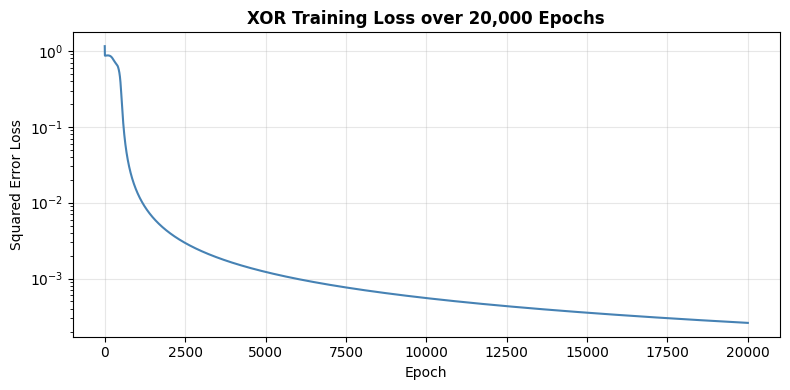


Learned hidden layer weights (approx):
  Neuron 1: [6.95, 6.95, -3.15]
  Neuron 2: [5.12, 5.12, -7.84]
Learned output layer weights (approx):
  Neuron 1:  [10.96, -11.63, -5.14]


In [81]:
# Plot the training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', lw=1.5)
plt.xlabel('Epoch'); plt.ylabel('Squared Error Loss')
plt.title('XOR Training Loss over 20,000 Epochs', fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nLearned hidden layer weights (approx):')
for i, neuron in enumerate(network_xor[0]):
    print(f'  Neuron {i+1}: {[round(w, 2) for w in neuron]}')
print('Learned output layer weights (approx):')
print(f'  Neuron 1:  {[round(w, 2) for w in network_xor[1][0]]}')

---
## 8. Case Study: FizzBuzz

Can a neural network learn the classic FizzBuzz rule from scratch —
without being told the rule explicitly?

> *For numbers 1–100: if divisible by 15 print "fizzbuzz", if divisible
> by 5 print "buzz", if divisible by 3 print "fizz", otherwise print
> the number.*

Before writing any code, we ask three questions that should guide
every machine learning problem.

---

### Question 1 — What is the problem?

> Given a number $n$, predict which of four categories it belongs to:
> plain number, fizz (divisible by 3), buzz (divisible by 5),
> or fizzbuzz (divisible by both 3 and 5).

This tells us immediately:
- We need **4 output classes**
- The network must detect **divisibility** — not size

That second point shapes every decision that follows.

---

### Question 2 — What are the inputs?

List what you know about the input:

- It is a whole number in the range 1–1023
- What matters is **not** its magnitude
- What matters **is** its relationship to 3, 5, and 15

The key insight: if size does not matter, encoding size (feeding the
raw number) is the wrong choice. The number 6 and the number 9 are
both fizz — but 9 is 50% larger than 6. Magnitude gives the wrong signal.

---

### Question 3 — How should I encode?

Ask: *what property of the input does the output depend on?*

| Output depends on | Encoding choice |
|---|---|
| Magnitude (size) | Raw number or normalised scalar |
| Category identity | One-hot vector |
| Internal structure | Representation that exposes that structure |
| Sequence and position | Ordered encoding (one slot per position) |

Exactly right. You have identified something important that is easy to miss.

---

### What we are NOT doing

We are not asking the network to do binary arithmetic. We are not teaching it what binary means. We are not using the mathematical properties of binary numbers.

---

### What we ARE doing

We are taking a number and spreading it across 10 separate inputs — one per bit — so the network has **10 independent signals** to work with instead of 1.

```
6  →  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
```

The network does not know these are bits. It just sees 10 numbers — each either 0 or 1. It treats them exactly like any other inputs and learns weights for each one.

---

### It is a representation choice — nothing more

The question was never "what is 6 in binary?" The question was:

> What representation of 6 gives the network the best chance of learning divisibility?

Binary happens to be a good answer because it spreads the number into 10 separate signals that carry structural information about divisibility. But the network never knows it is looking at binary.

---

### A useful analogy

Think of it like pixels in an image.

When a network classifies an image of a cat it does not understand pixels as a coordinate system. It just sees a grid of numbers — red, green, blue values at each position. The pixel representation happens to be a good way to spread the image into many independent signals the network can combine.

Binary encoding does the same thing for numbers:

```
raw number  →  1 signal    (like giving the network one pixel)
binary      →  10 signals  (like giving the network 10 pixels)
```

More signals = more for the network to work with.

---

### The precise statement for your notebook

```markdown
📝 Note — binary is a representation, not arithmetic

We are not asking the network to understand binary numbers.
We are using binary as a way to spread one number into 10
separate input signals — each 0 or 1 — that the network
can weight independently.

The network sees 10 numbers. It has no idea they came from
a binary representation. It simply learns which combinations
of those 10 signals predict fizz, buzz, or fizzbuzz.

Binary works here not because of its mathematical meaning
but because it is a compact way to expose the internal
structure of a number as separate trainable inputs.
```


> We use binary not because the network does binary arithmetic — it does not — but because spreading a number into 10 bits gives the network 10 independent inputs to combine, which happens to expose the structural patterns that divisibility depends on.

For FizzBuzz the output depends on **divisibility structure** →
binary encoding exposes that structure.


**The quick test:** if you doubled the input, should the output
change proportionally?

In [82]:
def fizz_buzz_encode(x: int) -> Vector:
    """One-hot encode a number into [number, fizz, buzz, fizzbuzz]."""
    if x % 15 == 0: return [0, 0, 0, 1]
    elif x % 5 == 0: return [0, 0, 1, 0]
    elif x % 3 == 0: return [0, 1, 0, 0]
    else:            return [1, 0, 0, 0]

def binary_encode(x: int) -> Vector:
    """10-bit binary encoding (LSB first)."""
    binary: List[float] = []
    for i in range(10):
        binary.append(x % 2)
        x = x // 2
    return binary

# Sanity checks (from Grus)
assert fizz_buzz_encode(2)  == [1, 0, 0, 0]
assert fizz_buzz_encode(6)  == [0, 1, 0, 0]
assert fizz_buzz_encode(10) == [0, 0, 1, 0]
assert fizz_buzz_encode(30) == [0, 0, 0, 1]
assert binary_encode(0)   == [0,0,0,0,0,0,0,0,0,0]
assert binary_encode(1)   == [1,0,0,0,0,0,0,0,0,0]
assert binary_encode(10)  == [0,1,0,1,0,0,0,0,0,0]
print('Encoding functions defined and verified ✓')

Encoding functions defined and verified ✓


In [83]:
# Build training data
xs_fb = [binary_encode(n)    for n in range(101, 1024)]
ys_fb = [fizz_buzz_encode(n) for n in range(101, 1024)]

print(f'Training examples: {len(xs_fb)}')
print(f'Input dimension:   {len(xs_fb[0])} (10 binary bits)')
print(f'Output dimension:  {len(ys_fb[0])} (one-hot: number/fizz/buzz/fizzbuzz)')

Training examples: 923
Input dimension:   10 (10 binary bits)
Output dimension:  4 (one-hot: number/fizz/buzz/fizzbuzz)


### 8.2 Network Architecture

```
Input (10)  →  Hidden (25)  →  Output (4)
```

- 10 input neurons (one per bit)
- 25 hidden neurons (tunable hyperparameter)
- 4 output neurons (one per class)


Total trainable parameters: $25 \times 11 = 275$ (hidden) + $4 \times 26 = 104$ (output) $= 379$

# Code Structure Reminder

```python
network_xor = [
    [[w, w, w], [w, w, w]],   ← hidden layer: 2 neurons × 3 weights
    [[w, w, w]]                ← output layer: 1 neuron  × 3 weights
]

```

Why 3 weights for 2 inputs? One extra for the bias term.

So the full shape is:
```python
network_xor → list[layer]
each layer → list[neuron]
each neuron → list[weight] (inputs + 1 bias)

```
```python
# understand list comprehension
network_fb = [
            [gradient_step(neuron, grad, -learning_rate)
             for neuron, grad in zip(layer, layer_grad)]
            for layer, layer_grad in zip(network_fb, gradients)
        ]
```

```python
network_fb = []
for layer, layer_grad in zip(network_fb, gradients):      # outer
    new_layer = []
    for neuron, grad in zip(layer, layer_grad):             # inner
        new_layer.append(gradient_step(neuron, grad, -learning_rate))
    new_network.append(new_layer)
network_fb = new_network
```

In [84]:
print(xs_fb[0:5])
ys_fb[0:5]

[[1, 0, 1, 0, 0, 1, 1, 0, 0, 0], [0, 1, 1, 0, 0, 1, 1, 0, 0, 0], [1, 1, 1, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 1, 0, 1, 1, 0, 0, 0], [1, 0, 0, 1, 0, 1, 1, 0, 0, 0]]


[[1, 0, 0, 0], [0, 1, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0], [0, 0, 0, 1]]

# Network Architecture

In the following code chunk, we will be creating this code architecture

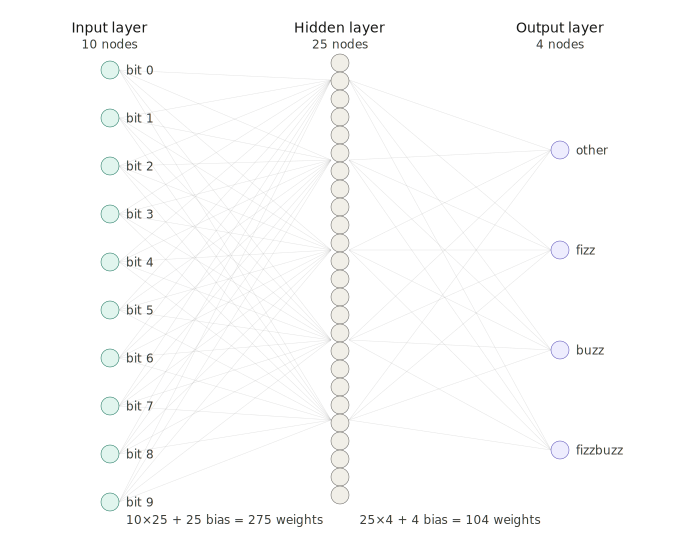

In [85]:
# @title
from IPython.display import SVG, display

url = "https://raw.githubusercontent.com/ravichas/bifx-546/refs/heads/main/images/fizzbuzz_network_static.svg"
import requests
svg_content = requests.get(url).text
display(SVG(svg_content))

In [86]:
random.seed(0)
NUM_HIDDEN = 25

network_fb = [
    # Hidden: 10 inputs (+1 bias) → NUM_HIDDEN neurons
    [[random.random() for _ in range(10 + 1)] for _ in range(NUM_HIDDEN)],
    # Output: NUM_HIDDEN inputs (+1 bias) → 4 neurons
    [[random.random() for _ in range(NUM_HIDDEN + 1)] for _ in range(4)]
]

from scratch.linear_algebra import squared_distance

learning_rate = 1.0
fb_loss_history = []
EPOCHS = 500

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for x, y in zip(xs_fb, ys_fb):
        predicted = feed_forward(network_fb, x)[-1]
        epoch_loss += squared_distance(predicted, y)
        gradients = sqerror_gradients(network_fb, x, y)
        network_fb = [
            [gradient_step(neuron, grad, -learning_rate)
             for neuron, grad in zip(layer, layer_grad)]
            for layer, layer_grad in zip(network_fb, gradients)
        ]
    fb_loss_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{EPOCHS}  |  Loss: {epoch_loss:.2f}')

print('\nTraining complete!')

Epoch  100/500  |  Loss: 589.02
Epoch  200/500  |  Loss: 208.55
Epoch  300/500  |  Loss: 91.00
Epoch  400/500  |  Loss: 43.26
Epoch  500/500  |  Loss: 27.41

Training complete!


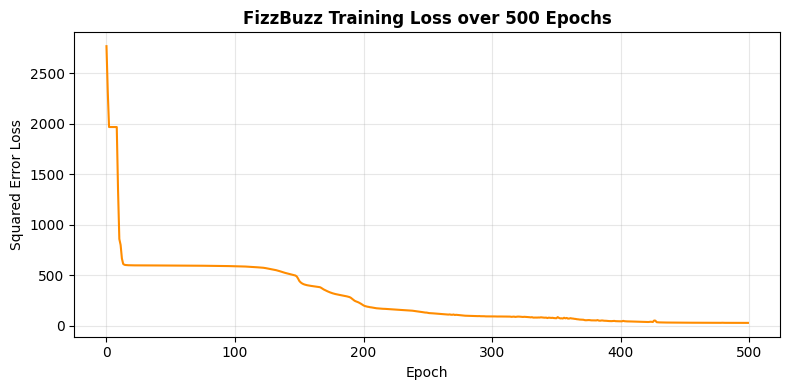

In [87]:
plt.figure(figsize=(8, 4))
plt.plot(fb_loss_history, color='darkorange', lw=1.5)
plt.xlabel('Epoch'); plt.ylabel('Squared Error Loss')
plt.title('FizzBuzz Training Loss over 500 Epochs', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Evaluation on 1–100

We decode the network's 4-dimensional output using **argmax** — the index of the largest value.

$$\widehat{c} = \arg\max_k \widehat{y}_k$$

In [88]:
def argmax(xs: list) -> int:
    """Return the index of the largest element."""
    return max(range(len(xs)), key=lambda i: xs[i])

labels = ['number', 'fizz', 'buzz', 'fizzbuzz']
num_correct = 0
errors = []

for n in range(1, 101):
    x         = binary_encode(n)
    predicted = argmax(feed_forward(network_fb, x)[-1])
    actual    = argmax(fizz_buzz_encode(n))
    correct   = (predicted == actual)
    if correct:
        num_correct += 1
    else:
        errors.append((n, labels[predicted], labels[actual]))

print(f'Accuracy on 1–100: {num_correct}/100 ({num_correct}%)')
if errors:
    print(f'\nMistakes ({len(errors)}):')
    for n, pred, true in errors:
        print(f'  n={n:3d}  predicted={pred:<10}  actual={true}')

Accuracy on 1–100: 96/100 (96%)

Mistakes (4):
  n=  4  predicted=fizz        actual=number
  n= 34  predicted=fizz        actual=number
  n= 70  predicted=number      actual=buzz
  n=100  predicted=number      actual=buzz


---
## 9. Key Concepts & Common Pitfalls

### Activation Functions

| Function | Formula | Pros | Cons |
|---|---|---|---|
| Step | **1**[z ≥ 0] | Intuitive | Not differentiable |
| Sigmoid | 1 / (1 + e⁻ᶻ) | Smooth, probabilistic | Vanishing gradient |
| ReLU | max(0, z) | Fast, no vanishing gradient | Dying neurons |
| Tanh | (eᶻ − e⁻ᶻ) / (eᶻ + e⁻ᶻ) | Zero-centred | Vanishing gradient |


### Hyperparameters vs Parameters

- **Parameters** (learned): weights and biases → updated by gradient descent
- **Hyperparameters** (set by you): learning rate, number of hidden neurons, number of layers, epochs

### Common Pitfalls

- **Vanishing gradients** — sigmoid saturates; deep networks struggle to propagate gradients
- **Overfitting** — large networks memorise training data; use regularisation, dropout, early stopping
- **Poor weight initialisation** — random uniform is acceptable for small nets; Xavier/He for deep nets
- **Learning rate too high** — loss oscillates or diverges; too low — training never converges
- **No normalisation** — features on vastly different scales make gradient descent erratic

### 🧬 Bioinformatics Applications

- **Multi-layer perceptron (MLP)** — gene expression classification, phenotype prediction
- **Convolutional neural network (CNN)** — DNA/protein sequence motif detection
- **Recurrent neural network (RNN/LSTM)** — time-series genomics, EHR modelling
- **Graph neural network (GNN)** — protein–protein interaction networks
- **Transformer** — protein language models (ESM-2), AlphaFold2

---
## 10. Exercises

**Exercise 1** — Implement a NAND gate (NOT-AND) using a perceptron. Verify all four input combinations.

**Exercise 2** — Modify `feed_forward` to return only the final output layer (not all intermediate layers). When would this simplified version be sufficient? When would it fail?

**Exercise 3** — Change `NUM_HIDDEN` to 10, 50, and 100 in the FizzBuzz network. How does accuracy and training time change?

**Exercise 4** — Plot the training loss for the FizzBuzz network on a **log scale**. Does it look like it has converged by epoch 500? What would you do if it hasn't?

**Exercise 5 (Bioinformatics)** — A researcher wants to classify gene expression profiles (500 genes) into 3 cancer subtypes. Sketch a suitable MLP architecture: how many input neurons? Output neurons? How many hidden layers and neurons would you try first?

**Exercise 6 (Advanced)** — The `sqerror_gradients` function currently supports only one hidden layer. Describe — in pseudocode or words — how you would generalise it to $L$ hidden layers.

---
## 11. What's Next

In this course we built a neural network **from scratch** to deeply understand the mechanics. In practice, you would use a framework like **PyTorch** or **TensorFlow/Keras**, which provides:

- Automatic differentiation (autograd)
- GPU acceleration
- Pre-built layers, optimisers, and regularisers
- Transfer learning from pre-trained models

Coming up: **Chapter 21 — Natural Language Processing**, where we apply similar neural ideas to text data — a foundation for understanding large language models.

---
*End of Chapter 18 Notebook*